In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
df = pd.read_csv('Facebook_Marketplace_data.csv')
df.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


In [3]:
df = df.drop(columns=['Column1','Column2','Column3','Column4'], errors='ignore')

In [4]:
df['status_published'] = pd.to_datetime(df['status_published'])

In [8]:
df.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,hour
0,1,video,2018-04-22 06:00:00,529,512,262,432,92,3,1,1,0,6
1,2,photo,2018-04-21 22:45:00,150,0,0,150,0,0,0,0,0,22
2,3,video,2018-04-21 06:17:00,227,236,57,204,21,1,1,0,0,6
3,4,photo,2018-04-21 02:29:00,111,0,0,111,0,0,0,0,0,2
4,5,photo,2018-04-18 03:22:00,213,0,0,204,9,0,0,0,0,3


In [6]:
df['hour'] = df['status_published'].dt.hour

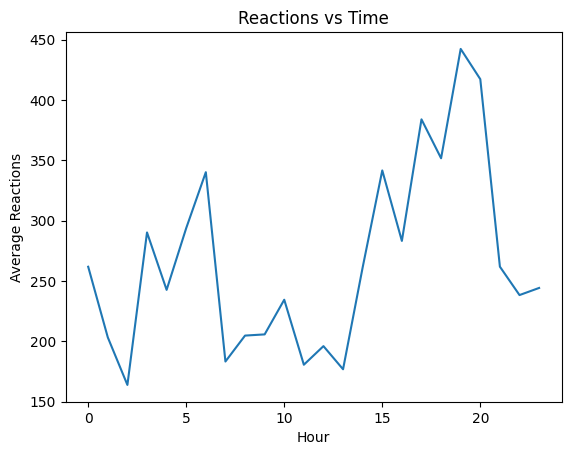

In [7]:
hourly_reactions = df.groupby('hour')['num_reactions'].mean()
hourly_reactions.plot(kind='line')
plt.xlabel("Hour")
plt.ylabel("Average Reactions")
plt.title("Reactions vs Time")
plt.show()

In [9]:
corr = df[['num_reactions','num_comments','num_shares']].corr()
print(corr)

               num_reactions  num_comments  num_shares
num_reactions       1.000000      0.150843    0.250723
num_comments        0.150843      1.000000    0.640637
num_shares          0.250723      0.640637    1.000000


In [10]:
le = LabelEncoder()
df['status_type_encoded'] = le.fit_transform(df['status_type'])

In [11]:
features = df[['status_type_encoded','num_reactions','num_comments','num_shares',
               'num_likes','num_loves','num_wows','num_hahas','num_sads','num_angrys']]

In [13]:
scaler = StandardScaler()
X = scaler.fit_transform(features)

In [14]:
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X)

KMeans(n_clusters=3, random_state=0)

In [15]:
df['cluster'] = kmeans.labels_

In [16]:
df[['status_type','cluster']].head()

,status_type,cluster
0,video,1
1,photo,1
2,video,1
3,photo,1
4,photo,1


In [17]:
wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

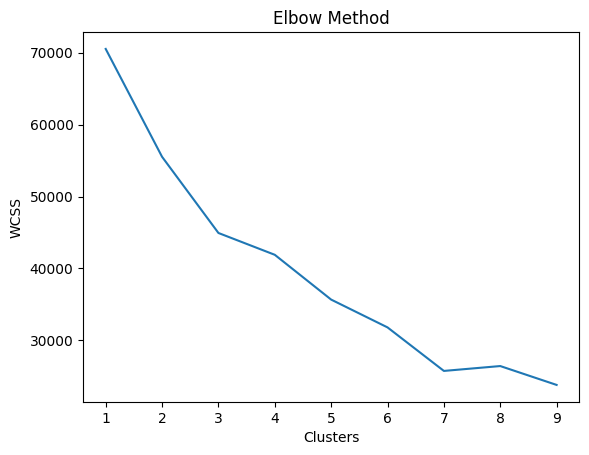

In [18]:
plt.plot(range(1,10), wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [19]:
df['status_type'].value_counts()

,count
status_type,
photo,4288
video,2334
status,365
link,63


In [20]:
df.groupby('status_type')[['num_reactions','num_comments','num_shares']].mean()

,num_reactions,num_comments,num_shares
status_type,,,
link,370.142857,5.698413,4.396825
photo,181.290345,15.993470,2.553871
status,438.783562,36.238356,2.558904
video,283.409597,642.478149,115.679949
